In [16]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd


In [17]:
loss_tracking_dir = Path("../loss_tracking")
db_paths = sorted(loss_tracking_dir.glob("loss_tracking_*.sqlite3"))

if not db_paths:
    raise FileNotFoundError(f"No SQLite loss history database found in {loss_tracking_dir.resolve()}")

db_path = max(db_paths, key=lambda path: path.stat().st_mtime)
print(f"Loading latest database: {db_path}")

with sqlite3.connect(db_path) as connection:
    loss_df = pd.read_sql_query(
        """
        SELECT
            lh.run_id,
            lh.epoch,
            lh.total_loss,
            lh.wirelength_loss,
            lh.overlap_loss,
            lh.overlap_count,
            lh.total_overlap_area,
            lh.max_overlap_area,
            r.runner,
            r.run_label,
            r.run_started_at,
            r.saved_at,
            r.num_epochs,
            r.lr,
            r.lambda_wirelength,
            r.lambda_overlap,
            r.log_interval,
            r.verbose,
            r.total_cells,
            r.total_pins,
            r.total_edges,
            COALESCE(tc.test_id, r.test_id) AS test_id,
            COALESCE(tc.num_macros, r.num_macros) AS num_macros,
            COALESCE(tc.num_std_cells, r.num_std_cells) AS num_std_cells,
            COALESCE(tc.seed, r.seed) AS seed
        FROM loss_history AS lh
        JOIN runs AS r ON r.run_id = lh.run_id
        LEFT JOIN test_cases AS tc ON tc.test_id = r.test_id
        ORDER BY tc.test_id, lh.run_id, lh.epoch
        """,
        connection,
    )

if "test_id" in loss_df.columns:
    loss_df["test_id"] = pd.to_numeric(loss_df["test_id"], errors="coerce").astype("Int64")

available_runs = (
    loss_df[["test_id", "seed", "run_id", "runner", "run_label", "saved_at"]]
    .drop_duplicates()
    .sort_values(["test_id", "run_id"], na_position="last")
    .reset_index(drop=True)
)

test_case_runs = (
    available_runs.groupby("test_id", dropna=False)
    .agg(
        run_count=("run_id", "nunique"),
        seeds=("seed", lambda s: sorted({int(v) for v in s.dropna()})),
        latest_run_id=("run_id", "max"),
    )
    .reset_index()
    .sort_values("test_id", na_position="last")
)

print(f"Loaded {len(available_runs)} runs from {db_path.resolve()}")
test_case_runs


Loading latest database: ../loss_tracking/loss_tracking_20260419_204825_830487.sqlite3
Loaded 1 runs from /Users/vrajpandya/repo/intern_challenge/loss_tracking/loss_tracking_20260419_204825_830487.sqlite3


,test_id,run_count,seeds,latest_run_id
0,<NA>,1,[42],20260419_204827_816977


In [18]:
available_runs


,test_id,seed,run_id,runner,run_label,saved_at
0,<NA>,42,20260419_204827_816977,placement.main,train_placement,2026-04-19T20:48:27


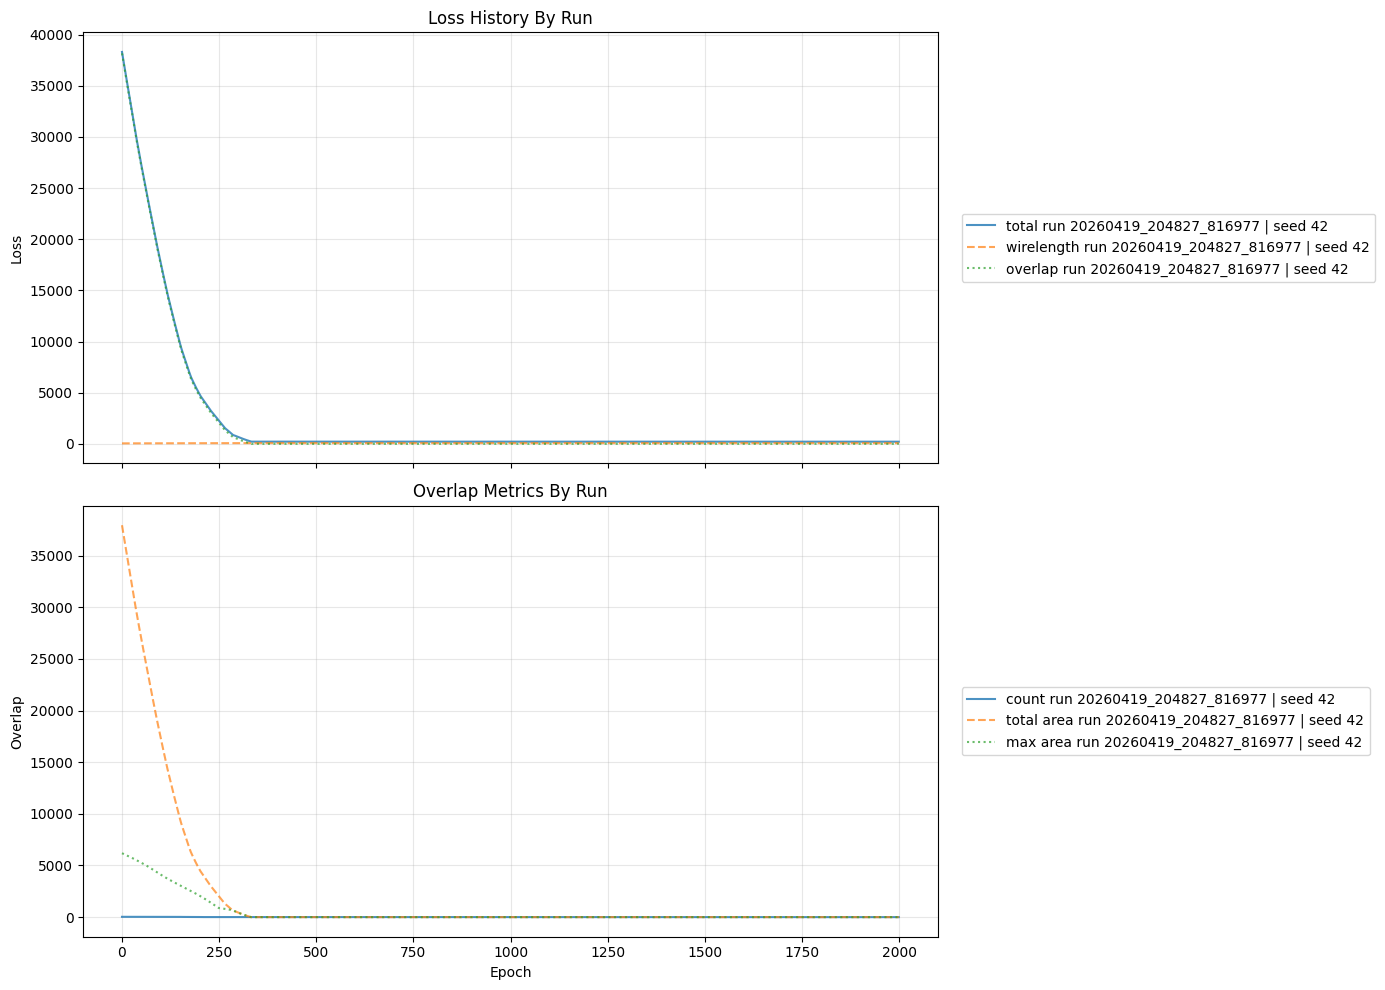

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for run_id, run_df in loss_df.groupby("run_id", sort=True):
    run_label = f"run {run_id}"
    if "test_id" in run_df.columns and run_df["test_id"].notna().any():
        run_label = f"test {int(run_df['test_id'].dropna().iloc[0])} | {run_label}"
    if "seed" in run_df.columns and run_df["seed"].notna().any():
        run_label = f"{run_label} | seed {int(run_df['seed'].dropna().iloc[0])}"

    axes[0].plot(run_df["epoch"], run_df["total_loss"], label=f"total {run_label}", alpha=0.8)
    axes[0].plot(
        run_df["epoch"],
        run_df["wirelength_loss"],
        linestyle="--",
        label=f"wirelength {run_label}",
        alpha=0.7,
    )
    axes[0].plot(
        run_df["epoch"],
        run_df["overlap_loss"],
        linestyle=":",
        label=f"overlap {run_label}",
        alpha=0.7,
    )

    if "overlap_count" in run_df.columns:
        axes[1].plot(run_df["epoch"], run_df["overlap_count"], label=f"count {run_label}", alpha=0.8)
    if "total_overlap_area" in run_df.columns:
        axes[1].plot(
            run_df["epoch"],
            run_df["total_overlap_area"],
            linestyle="--",
            label=f"total area {run_label}",
            alpha=0.7,
        )
    if "max_overlap_area" in run_df.columns:
        axes[1].plot(
            run_df["epoch"],
            run_df["max_overlap_area"],
            linestyle=":",
            label=f"max area {run_label}",
            alpha=0.7,
        )

axes[0].set_ylabel("Loss")
axes[0].set_title("Loss History By Run")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Overlap")
axes[1].set_title("Overlap Metrics By Run")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
